# GPQR Tutoral

Gaussian process quantile regression (GPQR) estimates quantile function using Gaussian process regression.

In this tutorial, we estimate multiple quantile levels for data with heteroscadastic noise. To avoid quantile crossing, multitask center-gap architecture with informative prior is used.

In [ ]:
%config InlineBackend.figure_formats = ['svg']

In [ ]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42);

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x = torch.linspace(0, 1, 100).reshape(-1, 1)
y = (mean(x) + torch.randn(x.shape).mul(std(x))).squeeze()
q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9])
true_quantiles = mean(x) + std(x) * torch.distributions.Normal(0, 1).icdf(q)

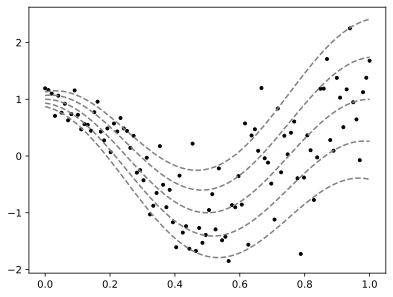

In [ ]:
plt.scatter(x, y, c="k", marker=".")
plt.plot(x, true_quantiles, "--", c="gray")
plt.show()